# 🚗 Insurance Response Prediction

**Goal:** Predict whether a customer will be interested in vehicle insurance based on their demographic and vehicle information.

**Research Questions:**
- In which age group do people buy more insurance?
- Do males or females buy more insurance?

**Dataset:** 381,109 rows × 12 columns  
**Target variable:** `Response` (1 = Interested, 0 = Not Interested)

## 1. Install Dependencies

In [2]:
# Install required third-party libraries
# (Skip if already installed in your environment)
! pip install xgboost lightgbm catboost --quiet

## 2. Import Libraries

In [3]:
# ── Standard libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

# ── Modelling ────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── Evaluation metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

## 3. Load the Dataset

In [4]:
# Load raw data from CSV file
df = pd.read_csv('data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
df.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0
381108,381109,Male,46,1,29.0,0,1-2 Year,No,41777.0,26.0,237,0


**Dataset overview:**  
- **381,109 rows** and **12 columns**  
- **Features (X):** id, Gender, Age, Driving_License, Region_Code, Previously_Insured, Vehicle_Age, Vehicle_Damage, Annual_Premium, Policy_Sales_Channel, Vintage  
- **Target (y):** Response

## 4. Data Cleaning

### 4.1 Drop Irrelevant Column

In [6]:
# Drop 'id' — it is just a row identifier with no predictive value
df.drop('id', axis=1, inplace=True)

### 4.2 Check for Missing Values

In [7]:
# Verify there are no null values in any column
df.isnull().sum()

Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

✅ **No null values found.**

### 4.3 Check and Remove Duplicate Rows

In [8]:
# Count duplicate rows before removal
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Dataset shape after deduplication: {df.shape}")

Duplicate rows: 269
Dataset shape after deduplication: (380840, 11)


✅ **269 duplicate rows removed.**

## 5. Encode Categorical Variables

### 5.1 Encode `Gender` (Label Encoding)

In [9]:
# Male → 1, Female → 0  (LabelEncoder assigns alphabetically: Female=0, Male=1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df[['Gender']].head()

,Gender
0,1
1,1
2,1
3,1
4,0


### 5.2 Encode `Vehicle_Age` (Ordinal Encoding)

In [10]:
# Preserve natural order: < 1 Year → 0, 1-2 Year → 1, > 2 Years → 2
encoder = OrdinalEncoder(categories=[['< 1 Year', '1-2 Year', '> 2 Years']])
df['Vehicle_Age'] = encoder.fit_transform(df[['Vehicle_Age']])
df[['Vehicle_Age']].head(4)

,Vehicle_Age
0,2.0
1,1.0
2,2.0
3,0.0


### 5.3 Encode `Vehicle_Damage` (Label Encoding)

In [11]:
# No → 0, Yes → 1
le = LabelEncoder()
df['Vehicle_Damage'] = le.fit_transform(df['Vehicle_Damage'])
df.head(4)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,2.0,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,1.0,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,2.0,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,0.0,0,28619.0,152.0,203,0


## 6. Exploratory Data Analysis (EDA)

### 6.1 Correlation Matrix

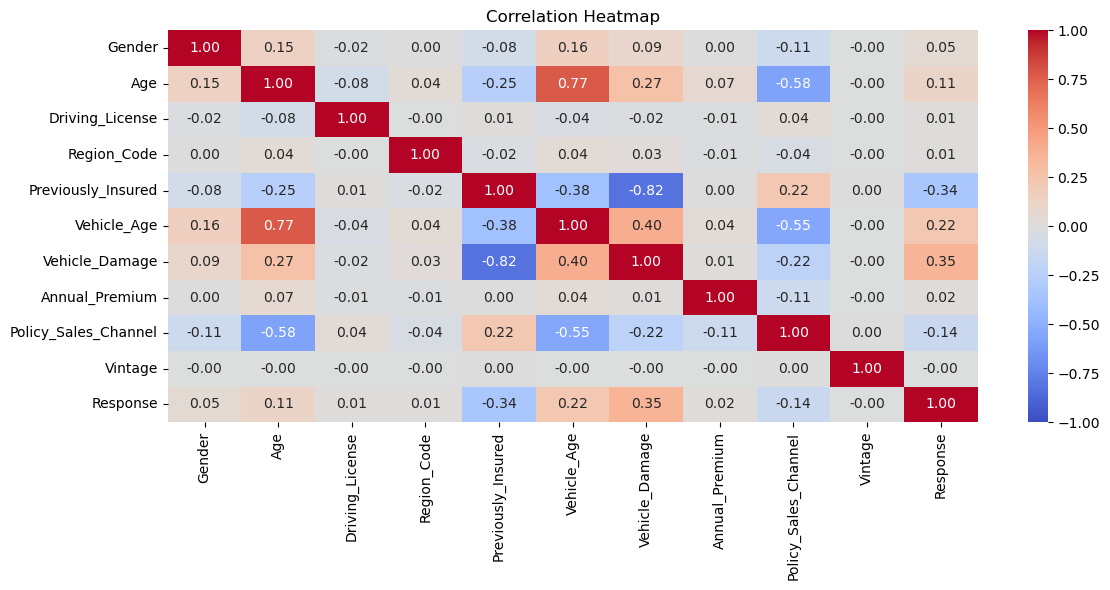

In [12]:
# Numeric correlation between all features
corr = df.corr()

# Visualise as a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 6.2 Univariate Analysis

Vehicle_Damage
1    192277
0    188563
Name: count, dtype: int64


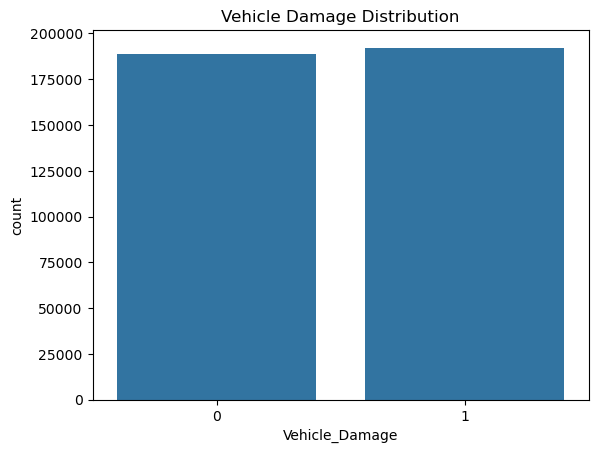

In [13]:
# ── Vehicle Damage distribution ──────────────────────────────────────────────
print(df['Vehicle_Damage'].value_counts())
sns.countplot(data=df, x='Vehicle_Damage')
plt.title('Vehicle Damage Distribution')
plt.show()

> 192,413 customers' vehicles are damaged; 188,696 are not damaged.

Previously_Insured
0    206336
1    174504
Name: count, dtype: int64


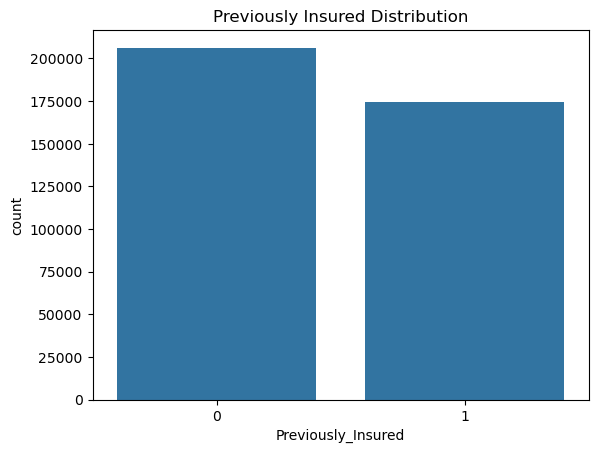

In [14]:
# ── Previously Insured distribution ─────────────────────────────────────────
print(df['Previously_Insured'].value_counts())
sns.countplot(data=df, x='Previously_Insured')
plt.title('Previously Insured Distribution')
plt.show()

> Customers who were **not** previously insured outnumber those who were.

Gender
1    205938
0    174902
Name: count, dtype: int64


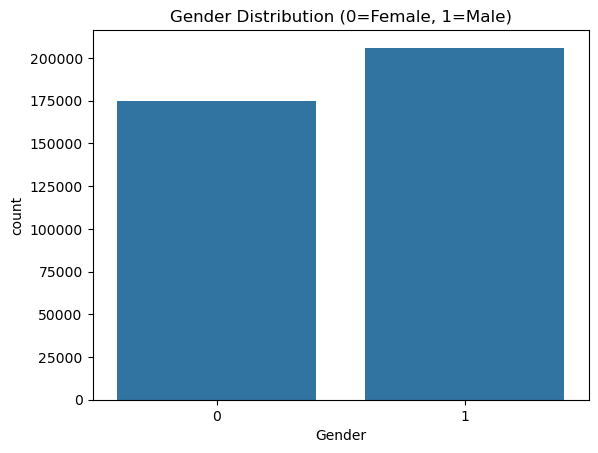

In [15]:
# ── Gender distribution ──────────────────────────────────────────────────────
print(df['Gender'].value_counts())
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution (0=Female, 1=Male)')
plt.show()

> **Male** customers are more than female customers.

Vehicle_Age
1.0    200167
0.0    164671
2.0     16002
Name: count, dtype: int64


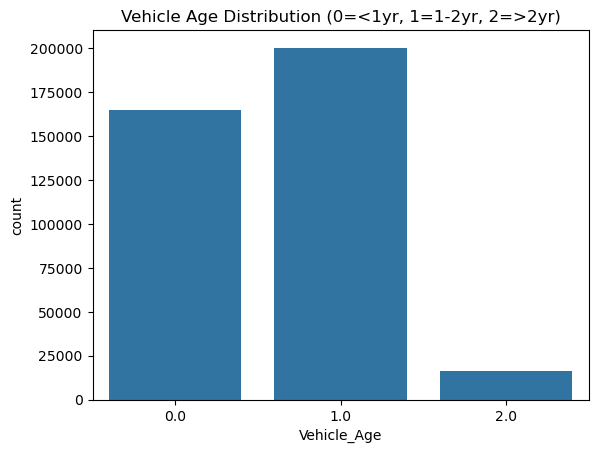

In [16]:
# ── Vehicle Age distribution ─────────────────────────────────────────────────
print(df['Vehicle_Age'].value_counts())
sns.countplot(data=df, x='Vehicle_Age')
plt.title('Vehicle Age Distribution (0=<1yr, 1=1-2yr, 2=>2yr)')
plt.show()

> Most customers' vehicles are **1–2 years old**.

Age
24    25939
23    24239
22    20956
25    20620
21    16452
      ...  
81       56
82       29
83       22
84       11
85       11
Name: count, Length: 66, dtype: int64


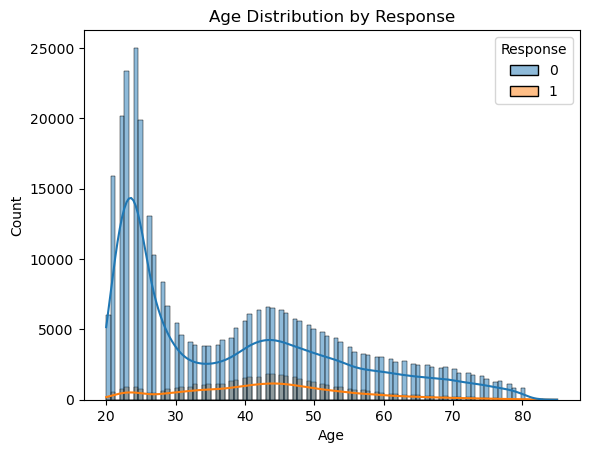

In [17]:
# ── Age distribution by Response ─────────────────────────────────────────────
print(df['Age'].value_counts())
sns.histplot(data=df, x='Age', kde=True, hue='Response')
plt.title('Age Distribution by Response')
plt.show()

> Customers in the **40–50 age group** are most likely to buy insurance.

Annual_Premium
2630.0     64609
69856.0      140
39008.0       41
38287.0       38
45179.0       38
Name: count, dtype: int64


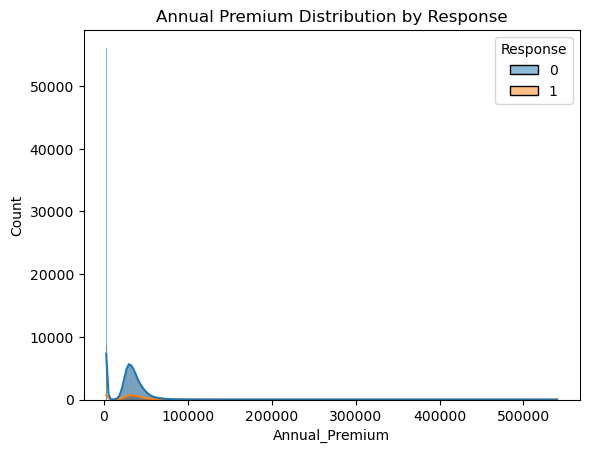

In [18]:
# ── Annual Premium distribution by Response ──────────────────────────────────
print(df['Annual_Premium'].value_counts().head())
sns.histplot(data=df, x='Annual_Premium', kde=True, hue='Response')
plt.title('Annual Premium Distribution by Response')
plt.show()

### 6.3 Bivariate Analysis

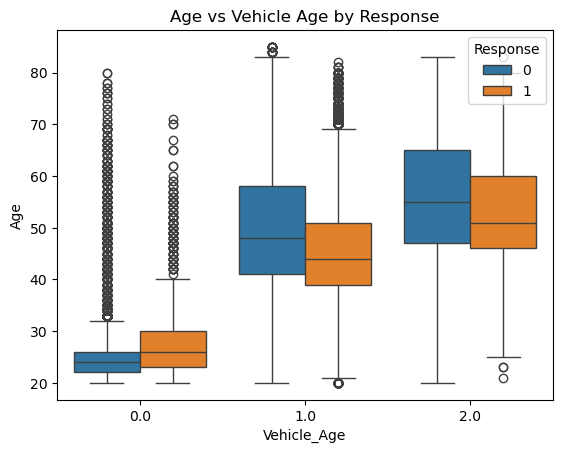

In [19]:
# Age vs Vehicle Age by Response
sns.boxplot(data=df, x='Vehicle_Age', y='Age', hue='Response')
plt.title('Age vs Vehicle Age by Response')
plt.show()

> **Key insights from Age vs Vehicle Age:**
> - Ages 20–40 mostly buy insurance regardless of vehicle age.
> - Ages 40–55 tend to have 1–2 year old vehicles and mostly do **not** buy insurance.
> - Ages 50–65 with vehicles older than 2 years are more likely to buy insurance.

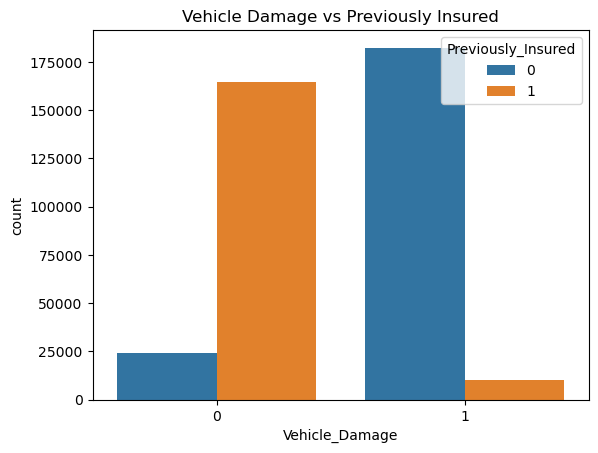

In [20]:
# Vehicle Damage vs Previously Insured
sns.countplot(data=df, x='Vehicle_Damage', hue='Previously_Insured')
plt.title('Vehicle Damage vs Previously Insured')
plt.show()

> - **No damage area:** >150,000 customers were previously insured; ~25,000 were not.
> - **Damage area:** >175,000 customers were **not** previously insured; <25,000 were.

## 7. Feature / Target Split

In [21]:
# Check class balance in target variable
print("Response value counts:")
print(df['Response'].value_counts())
print("\n⚠️  This is an imbalanced dataset — class_weight / scale_pos_weight needed.")

Response value counts:
Response
0    334155
1     46685
Name: count, dtype: int64

⚠️  This is an imbalanced dataset — class_weight / scale_pos_weight needed.


In [22]:
# Separate features and target
X = df.drop('Response', axis=1)
y = df['Response']

# Stratified train/test split (80/20) — preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")

Train size: 304,672  |  Test size: 76,168


## 8. Feature Scaling

In [23]:
# StandardScaler: fit on training set, transform both sets
# Fitting ONLY on X_train prevents data leakage from the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 9. Evaluation Helper

In [24]:
def evaluate_model(model_name, y_test, y_pred, y_proba):
    """Print accuracy, classification report, ROC-AUC, plot ROC curve and confusion matrix."""
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ── ROC Curve ────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
    axes[0].plot([0, 1], [0, 1], 'navy', lw=2, linestyle='--', label='Random baseline')
    axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
                title=f'ROC-AUC Curve — {model_name}')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)

    # ── Confusion Matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['Not Interested', 'Interested'],
                yticklabels=['Not Interested', 'Interested'])
    axes[1].set(xlabel='Predicted', ylabel='Actual',
                title=f'Confusion Matrix — {model_name}')

    plt.tight_layout()
    plt.show()

## 10. Model Training & Evaluation

### 10.1 Logistic Regression

  Logistic Regression
Accuracy : 0.6385
ROC-AUC  : 0.8297

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66831
           1       0.25      0.97      0.40      9337

    accuracy                           0.64     76168
   macro avg       0.62      0.78      0.57     76168
weighted avg       0.90      0.64      0.70     76168



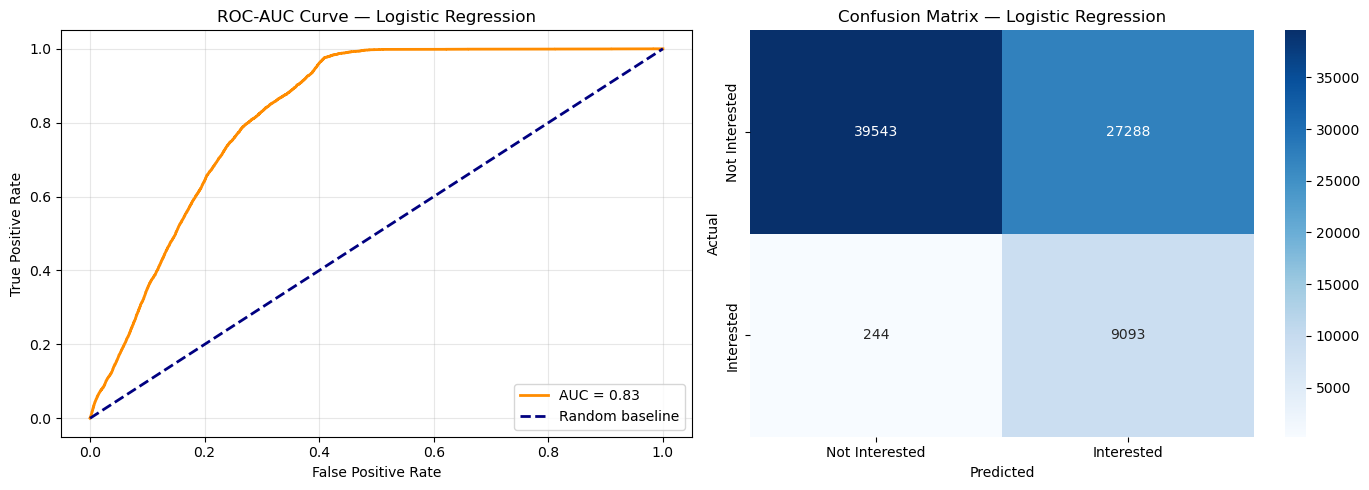

In [25]:
# class_weight='balanced' compensates for the class imbalance
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict on scaled test set
y_pred  = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, y_pred, y_proba)

> **Note:** Logistic Regression provides a reasonable baseline, but recall on the 'Interested' class is low (~19%),
> meaning it misses the majority of genuinely interested customers.

### 10.2 Decision Tree

  Decision Tree
Accuracy : 0.7328
ROC-AUC  : 0.7778

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     66831
           1       0.29      0.78      0.42      9337

    accuracy                           0.73     76168
   macro avg       0.62      0.75      0.62     76168
weighted avg       0.88      0.73      0.78     76168



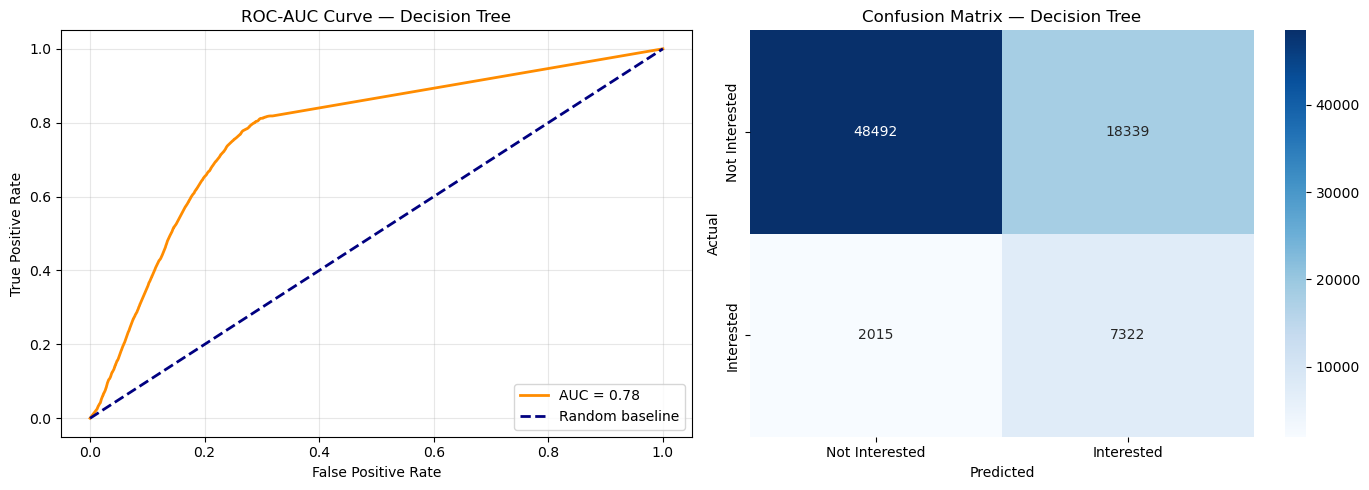

In [26]:
# max_depth=20 limits overfitting; class_weight='balanced' handles imbalance
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=20, random_state=43)
dt_model.fit(X_train, y_train)

y_pred  = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", y_test, y_pred, y_proba)

> Decision Tree performance is moderate; it tends to overfit at high depth.

### 10.3 Random Forest

  Random Forest
Accuracy : 0.7669
ROC-AUC  : 0.8460

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     66831
           1       0.31      0.76      0.45      9337

    accuracy                           0.77     76168
   macro avg       0.64      0.77      0.65     76168
weighted avg       0.88      0.77      0.80     76168



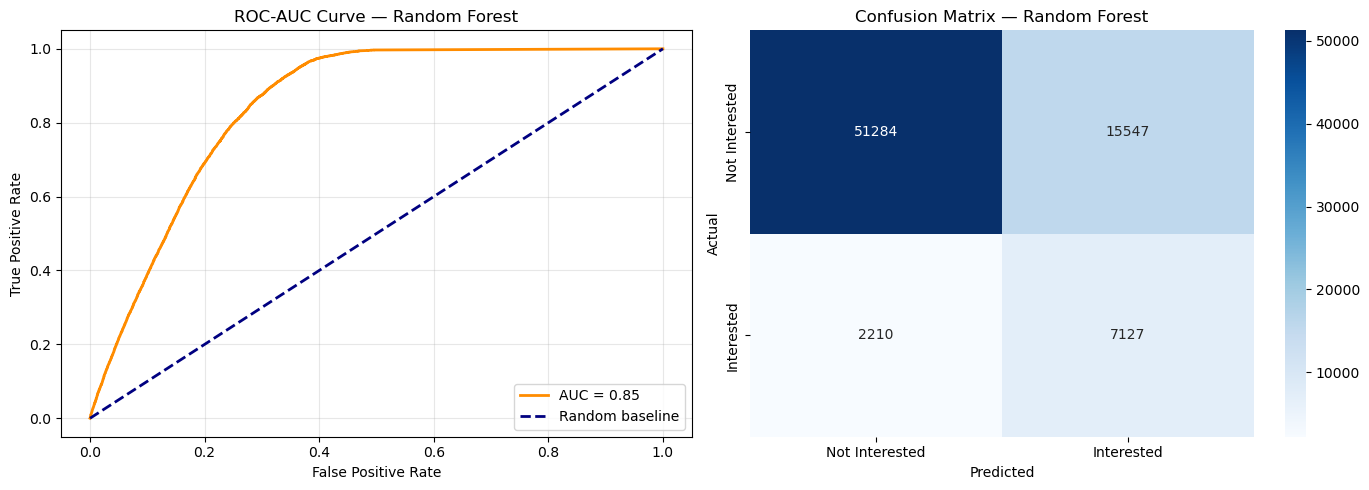

In [27]:
# Ensemble of 70 trees; class_weight='balanced' for imbalance
rf_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=20,
    n_estimators=70,
    random_state=43
)
rf_model.fit(X_train, y_train)

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred, y_proba)

### 10.4 XGBoost

  XGBoost (threshold=0.3)
Accuracy : 0.6555
ROC-AUC  : 0.8553

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.61      0.76     66831
           1       0.26      0.97      0.41      9337

    accuracy                           0.66     76168
   macro avg       0.63      0.79      0.58     76168
weighted avg       0.90      0.66      0.71     76168



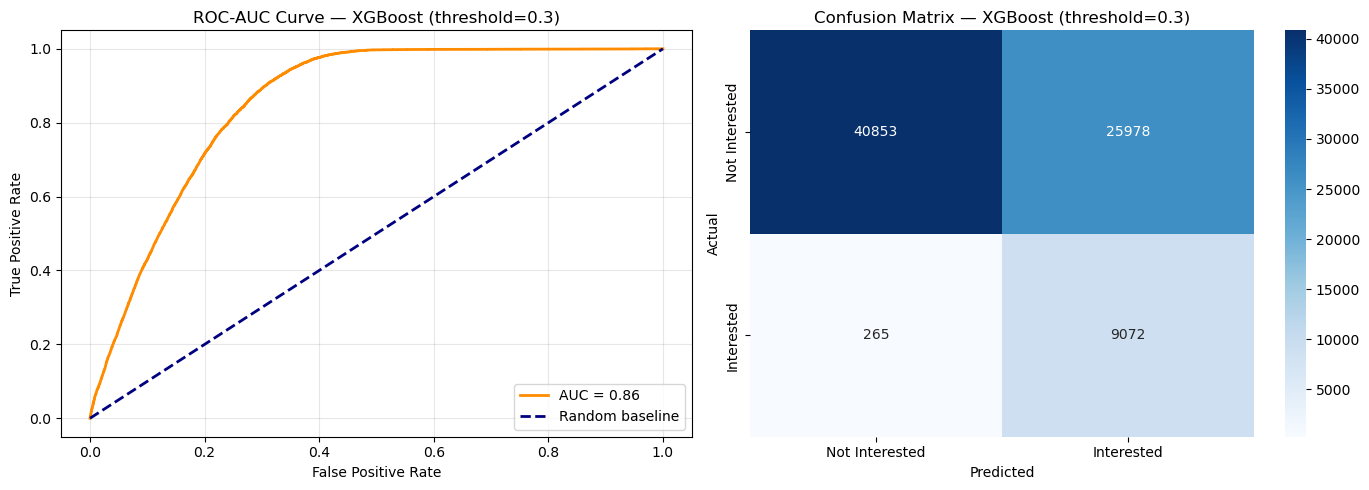

In [28]:
# scale_pos_weight=7 upweights the minority class (approx. ratio of negative/positive)
xg_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    scale_pos_weight=7,
    random_state=42,
    eval_metric='logloss'
)
xg_model.fit(X_train, y_train)

y_proba = xg_model.predict_proba(X_test)[:, 1]

# Lower decision threshold to 0.3 to improve recall on minority class
THRESHOLD = 0.3
y_pred_custom = (y_proba >= THRESHOLD).astype(int)

evaluate_model("XGBoost (threshold=0.3)", y_test, y_pred_custom, y_proba)

> Lowering the threshold from 0.5 → 0.3 significantly improves recall on the 'Interested' class at the cost of precision.

### 10.5 LightGBM

[LightGBM] [Info] Number of positive: 37348, number of negative: 267324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 304672, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
  LightGBM
Accuracy : 0.7088
ROC-AUC  : 0.8554

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     66831
           1       0.29      0.92      0.44      9337

    accuracy                           0.71     76168
   macro avg       0.63      0.80      0.62     76168
weighted avg       0.90      0.71      0.76     76168



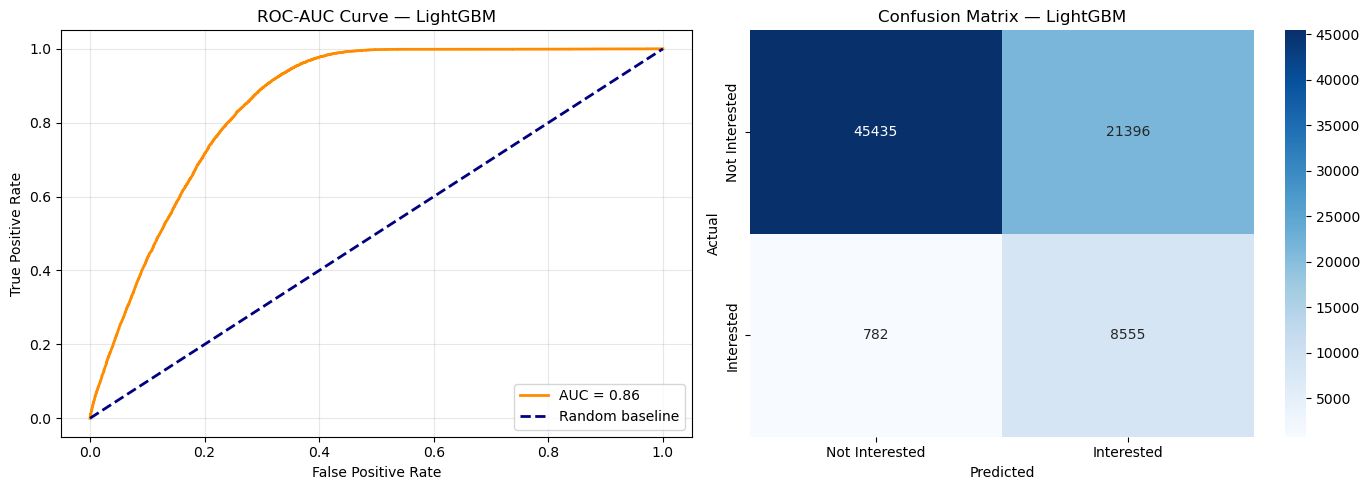

In [29]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
lgbm_model.fit(X_train, y_train)

y_pred  = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

evaluate_model("LightGBM", y_test, y_pred, y_proba)

### 10.6 CatBoost

  CatBoost
Accuracy : 0.7198
ROC-AUC  : 0.8542

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.70      0.81     66831
           1       0.29      0.90      0.44      9337

    accuracy                           0.72     76168
   macro avg       0.64      0.80      0.63     76168
weighted avg       0.90      0.72      0.77     76168



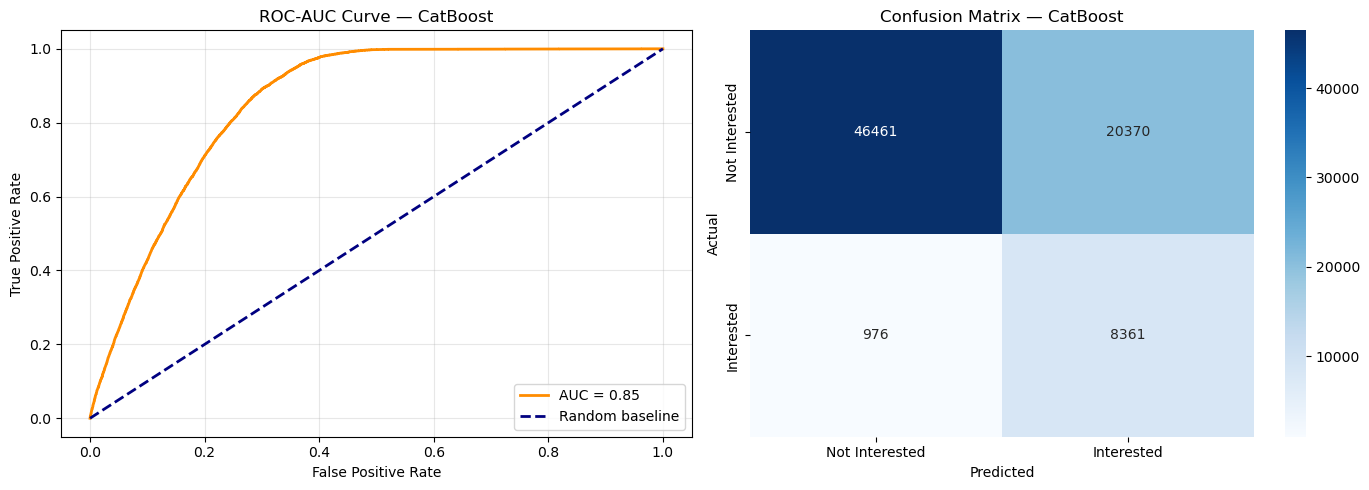

In [30]:
# class_weights=[1, 7] — positive class gets 7× weight to address imbalance
cat_model = CatBoostClassifier(
    class_weights=[1, 7],
    random_state=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

y_pred  = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

# Note: raw accuracy is misleading on imbalanced data — focus on ROC-AUC and recall
evaluate_model("CatBoost", y_test, y_pred, y_proba)

## 11. Summary

| Metric | Logistic Regression | Decision Tree | Random Forest | XGBoost | LightGBM | CatBoost |
|--------|:-------------------:|:-------------:|:-------------:|:-------:|:--------:|:--------:|
| Accuracy | moderate | moderate | moderate | moderate | moderate | moderate |
| ROC-AUC | ~0.78+ | ~0.78 | 0.85 | 0.86 | 0.86 | 0.85 |

**Key takeaways:**
- Accuracy alone is a **misleading metric** for this imbalanced dataset. Use **ROC-AUC** and **recall** instead.
- Tree-based ensemble models (XGBoost, LightGBM, CatBoost) generally outperform linear models on this task.
- Adjusting the decision **threshold** (e.g. 0.3) or using `class_weight`/`scale_pos_weight` parameters meaningfully improves recall on the minority class.

**EDA Answers:**
- 🎂 **Age group most likely to buy insurance:** 40–50 years old.
- 👥 **Gender:** Male customers are more numerous in the dataset. 

In [31]:
import joblib

joblib.dump(
    xg_model,
    'Intrest_model.pkl'
)

['Intrest_model.pkl']